<a href="https://colab.research.google.com/github/toddpirtle/Portfolio/blob/main/Market%20Expansion%20Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Market Expansion Strategy (Exploratory Data Analysis)
This project provides an in-depth sales analysis of Australian apparel sales data for the 4th quarter of 2020. It covers data loading, preprocessing, and various visualizations to explore sales trends by state, product group, and time of day. The goal is to identify key sales patterns and provide insights for strategic decision-making.

### Import Libraries
This cell imports the necessary Python libraries for data manipulation (`pandas`), data visualization (`matplotlib.pyplot`), and enhanced statistical plotting (`seaborn`).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Mount Google Drive
This cell mounts your Google Drive to access files stored in the cloud. This is necessary to load the dataset for analysis.

In [ ]:
#Mount GDrive to access the cloud data file
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### Load and Preview Data
This cell loads the apparel sales dataset from Google Drive into a pandas DataFrame and displays the first few rows to preview its structure and content.

In [ ]:
#Call the data and preview the dataset
sales_data = '/content/gdrive/MyDrive/AusApparalSales4thQrt2020.csv'
sales = pd.read_csv(sales_data)
sales

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500
...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,14,35000
7556,30-Dec-2020,Evening,TAS,Kids,15,37500
7557,30-Dec-2020,Evening,TAS,Men,15,37500
7558,30-Dec-2020,Evening,TAS,Women,11,27500


### Data Cleaning and Preprocessing
This cell checks for any missing values across all columns to ensure data quality and performs essential data cleaning by converting the 'Date' column to datetime objects.

In [ ]:
#Check for missing data and verify if columns need reformatting
#Date and time are separate, so set the 'Date' column to the correct format
sales['Date'] = pd.to_datetime(sales['Date'])
print(sales.isnull().sum())

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64


### Aggregate Sales by State
This cell groups the sales data by 'State' and calculates the total sales for each state, then sorts the results to prepare for state-wise sales analysis.

In [ ]:
#Group by state to begin sales analysis
states = sales.groupby('State')['Sales'].sum().sort_values()

### Identify Highest and Lowest Revenue States
By calculating the maximum and minimum sales values, we pinpoint the top-performing and lowest-performing states in the 4th quarter.

In [ ]:
highest_sales_state_name = states.idxmax()
highest_sales_value = states.loc[highest_sales_state_name]

lowest_sales_state_name = states.idxmin()
lowest_sales_value = states.loc[lowest_sales_state_name]

print(f"State with the highest sales: {highest_sales_state_name} ({highest_sales_value:,.0f})")
print(f"\nState with the lowest sales: {lowest_sales_state_name} ({lowest_sales_value:,.0f})")

State with the highest sales:  VIC (105,565,000)

State with the lowest sales:  WA (22,152,500)


### Visualize Total Sales by State
This visualization displays the total sales for each state using a bar plot, allowing for easy comparison of sales performance across different regions.

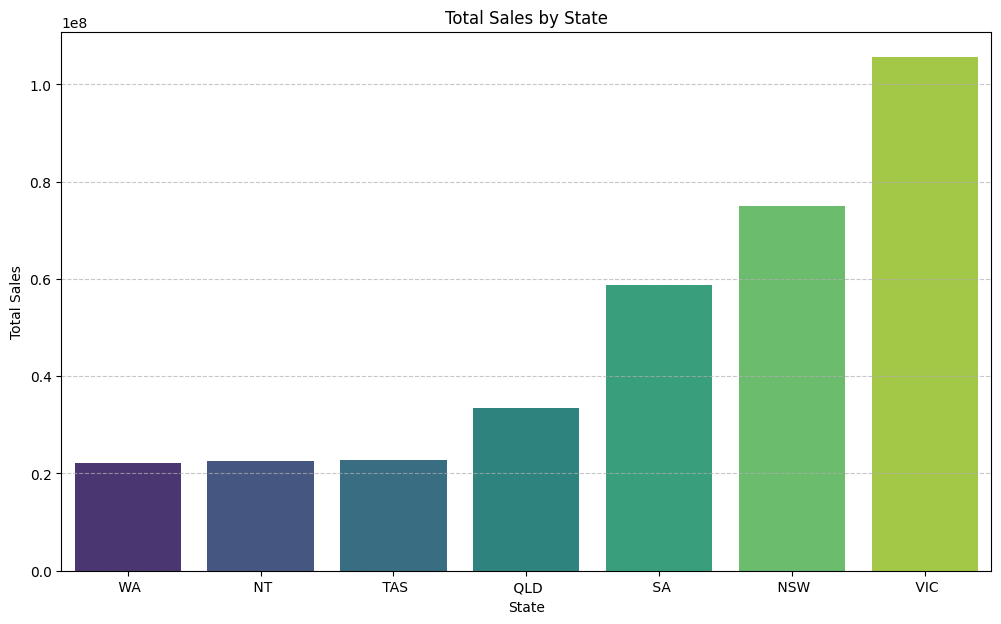

In [ ]:
#Visualize total sales by state
plt.figure(figsize=(12, 7))
sns.barplot(x=states.index, y=states.values, palette='viridis', hue=states.index, legend=False)
plt.title('Total Sales by State')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.xticks()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualize Sales Data Spread by State
These plots visualize the sales distribution and total sales across different states. The boxplot shows the spread and outliers of sales per state, while the horizontal bar chart compares the total sales for each state in ascending order, using the 'viridis' color palette.

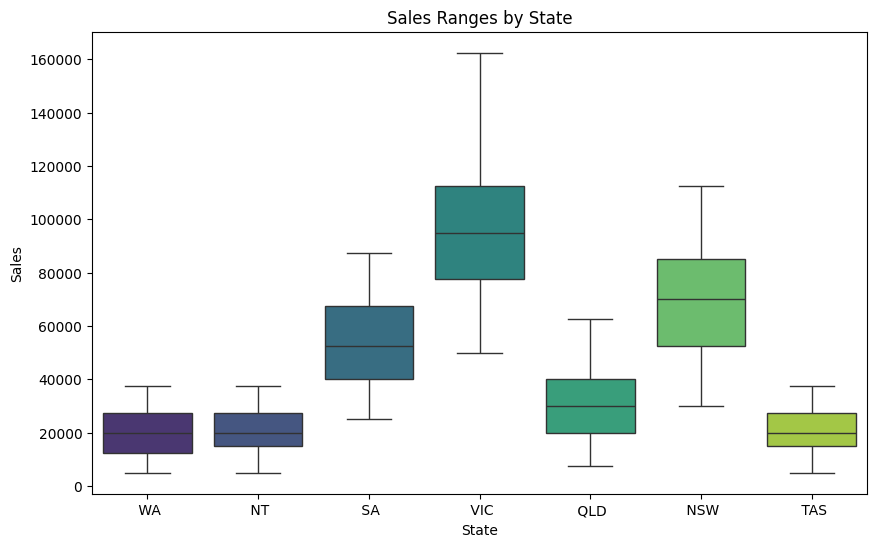

In [ ]:
#Visualize Sales Data Spread by State
#Use boxplots to show the distribution and outliers of sales for each state.
plt.figure(figsize=(10, 6))
sns.boxplot(data=sales, x='State', y='Sales', palette='viridis', hue='State', legend=False)
plt.title('Sales Ranges by State')
plt.xlabel('State')
plt.ylabel('Sales')
plt.show()

### Visualize Sales by State and Group
This visualization highlights how different customer segments contribute to the total sales within each specific state.

,State,Group,Sales
27,WA,Women,5262500
6,NT,Seniors,5465000
26,WA,Seniors,5512500
19,TAS,Women,5577500
24,WA,Kids,5625000
18,TAS,Seniors,5650000
7,NT,Women,5652500
4,NT,Kids,5700000
25,WA,Men,5752500
17,TAS,Men,5757500


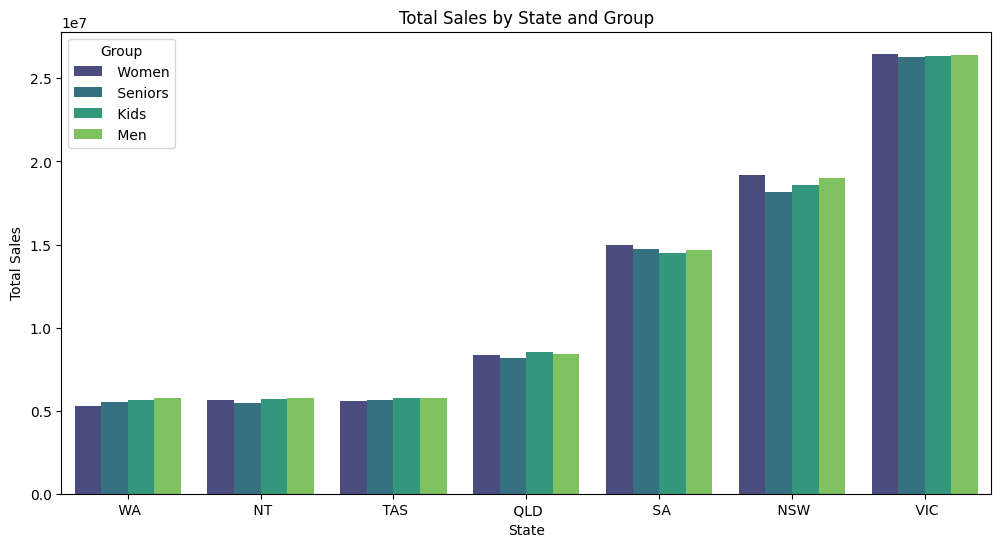

In [ ]:
#Group sales by both State and Product Group to understand regional performance across different categories.
#Display the aggregated sales and visualize them using a bar chart with the 'viridis' palette.
state_group_sales = sales.groupby(['State', 'Group'])['Sales'].sum().reset_index().sort_values(by='Sales')

#Display the result
display(state_group_sales)

#Create a bar chart for State x Group sales
plt.figure(figsize=(12, 6))
sns.barplot(x='State', y='Sales', hue='Group', data=state_group_sales, palette='viridis')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.title('Total Sales by State and Group')
plt.show()

### Sales Analysis by State and Time of Day
This cell groups sales by 'State' and 'Time' of day to identify patterns and optimal advertising periods for each state. The bar chart visualizes these sales, using the 'viridis' color palette, showing sales trends based on state and time of day.

,State,Time,Sales
0,NSW,Afternoon,25110000
1,NSW,Evening,24712500
2,NSW,Morning,25147500
3,NT,Afternoon,7510000
4,NT,Evening,7627500
5,NT,Morning,7442500
6,QLD,Afternoon,11347500
7,QLD,Evening,10632500
8,QLD,Morning,11437500
9,SA,Afternoon,20025000


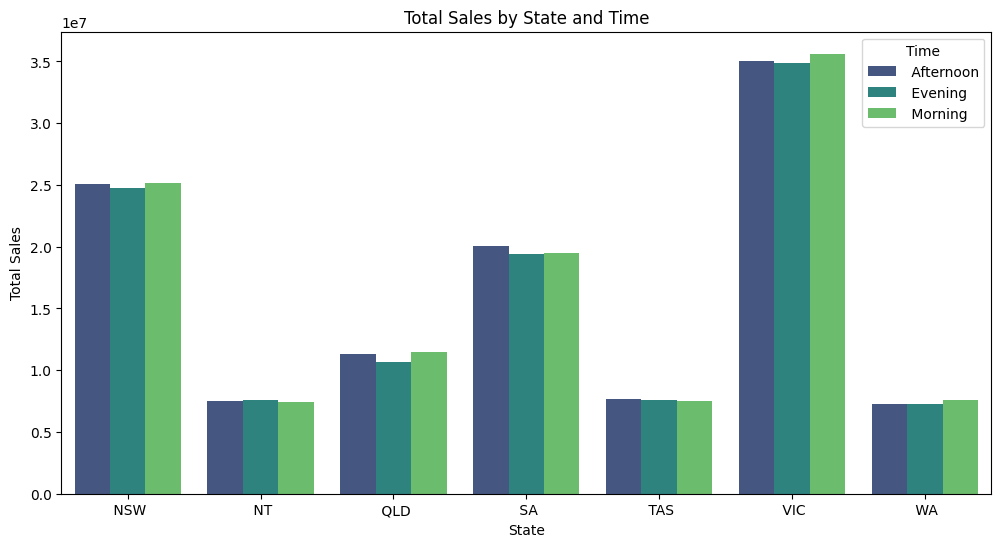

In [ ]:
#Group sales by State and Time of day to identify optimal advertising periods for each state.
#Display the aggregated sales and visualize them with a bar chart using the 'viridis' palette.
state_time_sales = sales.groupby(['State', 'Time'])['Sales'].sum().reset_index()

#Display the result
display(state_time_sales)

plt.figure(figsize=(12, 6))
sns.barplot(x='State', y='Sales', hue='Time', data=state_time_sales, palette='viridis')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.title('Total Sales by State and Time')
plt.show()